In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import seaborn as sns
from sklearn.impute import SimpleImputer
import numpy as np

In [ ]:
from pathlib import Path

DATA_DIR = Path("NHANES DATA")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Can't find the data folder at {DATA_DIR.resolve()}. "
        "Make sure 'NHANES DATA' is in the same folder as this notebook."
    )

ALL_YEARS = ["2013-2014", "2015-2016", "2017-2020", "2021-2023"]

def data_files(name, years=ALL_YEARS):
    """Build the list of .xpt paths for one dataset, e.g. data_files("glucose")."""
    return [DATA_DIR / f"{name}_{year}.xpt" for year in years]

gluocse_file_path = data_files("glucose")
smoking_file_path = data_files("smoking")
diet1_file_path = data_files("diet1")
diet2_file_path = data_files("diet2")
demographics_file_path = data_files("demographic")
physical_file_path = data_files("physical")
weight_file_path = data_files("weight")
sleep_file_path = data_files("sleep", ALL_YEARS[1:])  # 2013-2014 excluded bc titled SLD010H
alcohol_file_path = data_files("alcohol")
body_file_path = data_files("body")
medical_file_path = data_files("medical")
insurance_file_path = data_files("insurance")
blood_file_path = data_files("bloodpressure")

In [3]:
glucose_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'LBDGLUSI']] for file in gluocse_file_path]
glucose_df = pd.concat(glucose_dataframes, ignore_index=True)

smoking_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'SMQ020']] for file in smoking_file_path]
smoking_df = pd.concat(smoking_dataframes, ignore_index=True)

diet1_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB','DR1TSUGR', 'DR1TFIBE','DR1TTFAT', 'DR1TCHOL']] for file in diet1_file_path]
diet1_df = pd.concat(diet1_dataframes, ignore_index=True)

diet2_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'DR2TKCAL', 'DR2TPROT', 'DR2TCARB','DR2TSUGR', 'DR2TFIBE','DR2TTFAT', 'DR2TCHOL']] for file in diet2_file_path]
diet2_df = pd.concat(diet2_dataframes, ignore_index=True)

demographics_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'RIAGENDR', 'RIDAGEYR','RIDRETH1', 'INDFMPIR']] for file in demographics_file_path]
demographics_df = pd.concat(demographics_dataframes, ignore_index=True)

physical_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'PAD680']] for file in physical_file_path]
physical_df = pd.concat(physical_dataframes, ignore_index=True)

weight_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'WHD010', 'WHD020']] for file in weight_file_path]
weight_df = pd.concat(weight_dataframes, ignore_index=True)

sleep_dataframes = []

for file in sleep_file_path:
    df = pd.read_sas(file, format='xport')
    if 'SLD012' in df.columns:
        sleep_dataframes.append(df[['SEQN', 'SLD012']])
    elif 'SLD010H' in df.columns:
        sleep_dataframes.append(df[['SEQN', 'SLD010H']].rename(columns={'SLD010H': 'SLD012'}))  # Rename for consistency

sleep_df = pd.concat(sleep_dataframes, ignore_index=True)

alcohol_dataframes = []

for file in alcohol_file_path:
    df = pd.read_sas(file, format='xport')
    if 'ALQ111' in df.columns:
        alcohol_dataframes.append(df[['SEQN', 'ALQ111']])
    elif 'ALQ110' in df.columns:
        alcohol_dataframes.append(df[['SEQN', 'ALQ110']].rename(columns={'ALQ110': 'ALQ111'}))  # Rename for consistency

alcohol_df = pd.concat(sleep_dataframes, ignore_index=True)


body_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'BMXWAIST']] for file in body_file_path]
body_df = pd.concat(body_dataframes, ignore_index=True)

medical_dataframes = []

for file in medical_file_path:
    df = pd.read_sas(file, format='xport')
    
    if 'MCQ366B' in df.columns:
        medical_dataframes.append(df[['SEQN', 'MCQ300C', 'MCQ080', 'MCQ366A', 'MCQ366B', 'MCQ371A', 'MCQ371B', 'MCQ160C', 'MCQ160E', 'MCQ160B']])
    
    elif 'MCQ365B' in df.columns:
        renamed_df = df[['SEQN', 'MCQ300C', 'MCQ080', 'MCQ365A', 'MCQ365B', 'MCQ370A', 'MCQ370B', 'MCQ160C', 'MCQ160E', 'MCQ160B']].rename(
            columns={
                'MCQ365A': 'MCQ366A',
                'MCQ365B': 'MCQ366B',
                'MCQ370A': 'MCQ371A',
                'MCQ370B': 'MCQ371B'
            }
        )
        medical_dataframes.append(renamed_df)
medical_df = pd.concat(medical_dataframes, ignore_index=True)


insurance_dataframes = [pd.read_sas(file, format="xport")[['SEQN', 'HIQ011']] for file in insurance_file_path]
insurance_df = pd.concat(insurance_dataframes, ignore_index=True)

blood_dataframes = []

for file in blood_file_path:
    df = pd.read_sas(file, format='xport')
    
    if 'BPQ050A' in df.columns:
        blood_dataframes.append(df[['SEQN', 'BPQ020', 'BPQ080', 'BPQ050A', 'BPQ090D']])
    
    elif 'BPQ150' in df.columns:
        renamed_df = df[['SEQN', 'BPQ020', 'BPQ080', 'BPQ150', 'BPQ101D']].rename(
            columns={
                'BPQ150': 'BPQ050A',
                'BPQ101D': 'BPQ090D'
            }
        )
        blood_dataframes.append(renamed_df)
blood_df = pd.concat(blood_dataframes, ignore_index=True)


In [4]:
glucose_df.columns = ['ID', 'glucose']
smoking_df.columns=['ID', 'smoking']
diet1_df.columns=['ID', 'calories1', 'protein1','carbs1','sugar1','fiber1','fat1', 'cholesterol1']
diet2_df.columns=['ID', 'calories2', 'protein2','carbs2','sugar2','fiber2','fat2', 'cholesterol2']
demographics_df.columns = ['ID', 'gender', 'age', 'ethnicity', 'household income']
physical_df.columns=['ID', 'sedentary']
weight_df.columns=['ID', 'height', 'weight']
sleep_df.columns=['ID','hours of sleep']
alcohol_df.columns=['ID', 'ever had alcohol']

medical_df.columns=['ID','family history', 'doctor overweight', 'doctor lose weight', 'doctor exercise', 'losing weight', 'increasing exercise', 'heart disease', 'heart attack', 'heart failure']
insurance_df.columns=['ID', 'health insurance']
blood_df.columns=['ID', 'high blood pressure', 'high cholesterol', 'medication for HBP', 'prescription for cholesterol']
body_df.columns=['ID', 'waist']

In [5]:
#drop missing glucose values
glucose_df=glucose_df.dropna()

#diagnose diabetes from 2 hour fasting period according to WHO guidelines
glucose_df['diagnosis'] = glucose_df['glucose'].apply(lambda x: 1 if x > 7.0 else 0)
glucose_df.drop(columns=['glucose'], inplace=True)

In [6]:
#merge all dataframes into combined dataframe
combined_df = glucose_df.merge(smoking_df, on='ID', how='left')\
                         .merge(diet1_df, on='ID', how='left')\
                         .merge(diet2_df, on='ID', how='left')\
                         .merge(demographics_df, on='ID', how='left')\
                         .merge(physical_df, on='ID', how='left')\
                         .merge(weight_df, on='ID', how='left')\
                         .merge(sleep_df, on='ID', how='left')\
                         .merge(alcohol_df, on='ID', how='left')\
                         .merge(medical_df, on='ID', how='left')\
                         .merge(insurance_df, on='ID', how='left')\
                         .merge(blood_df, on='ID', how='left')\
                         .merge(body_df, on='ID', how="left")
combined_df.drop(columns=['ID'], inplace=True)

In [7]:
#create new column for BMI
combined_df['BMI'] = (703*combined_df['weight']) / (combined_df['height'] ** 2)

# Drop the original height and weight columns
combined_df.drop(columns=['height', 'weight'], inplace=True)

In [8]:
#create a new column of average of two days of nutrient tracking
nutrient_pairs = [
    ('calories1', 'calories2'),
    ('protein1', 'protein2'),
    ('fiber1', 'fiber2'),
    ('carbs1', 'carbs2'),
    ('fat1', 'fat2'),
    ('sugar1', 'sugar2'),
    ('cholesterol1', 'cholesterol2')
]

# Create new averaged column
for new_col, (col1, col2) in zip(['avg_' + pair[0] for pair in nutrient_pairs], nutrient_pairs):
    if col1 in combined_df.columns and col2 in combined_df.columns:
        combined_df[new_col] = combined_df[[col1, col2]].mean(axis=1)
    else:
        print(f"Warning: Columns {col1} or {col2} not found - skipping {new_col}")

# Now delete the old columns
cols_to_drop = []
for col1, col2 in nutrient_pairs:
    if col1 in combined_df.columns:
        cols_to_drop.append(col1)
    if col2 in combined_df.columns:
        cols_to_drop.append(col2)

combined_df = combined_df.drop(columns=cols_to_drop)

# Verify the new columns
print(combined_df.to_string())

       diagnosis  smoking  gender   age  ethnicity  household income     sedentary  hours of sleep  ever had alcohol  family history  doctor overweight  doctor lose weight  doctor exercise  losing weight  increasing exercise  heart disease  heart attack  heart failure  health insurance  high blood pressure  high cholesterol  medication for HBP  prescription for cholesterol  waist          BMI  avg_calories1  avg_protein1    avg_fiber1    avg_carbs1      avg_fat1    avg_sugar1  avg_cholesterol1
0              1      1.0     1.0  72.0        3.0      4.510000e+00  3.000000e+02             NaN               NaN             2.0                2.0                 2.0              2.0            2.0                  2.0            2.0           2.0            2.0               1.0                  1.0               1.0                 1.0                           1.0  109.2    27.976531   1.845000e+03  6.256000e+01  1.035000e+01  2.554300e+02  6.537000e+01  1.171300e+02      7.200000e+01
1 

In [9]:
combined_df = combined_df[combined_df.isnull().sum(axis=1) <= 10]
print(combined_df.to_string())

       diagnosis  smoking  gender   age  ethnicity  household income     sedentary  hours of sleep  ever had alcohol  family history  doctor overweight  doctor lose weight  doctor exercise  losing weight  increasing exercise  heart disease  heart attack  heart failure  health insurance  high blood pressure  high cholesterol  medication for HBP  prescription for cholesterol  waist          BMI  avg_calories1  avg_protein1    avg_fiber1    avg_carbs1      avg_fat1    avg_sugar1  avg_cholesterol1
0              1      1.0     1.0  72.0        3.0      4.510000e+00  3.000000e+02             NaN               NaN             2.0                2.0                 2.0              2.0            2.0                  2.0            2.0           2.0            2.0               1.0                  1.0               1.0                 1.0                           1.0  109.2    27.976531   1.845000e+03  6.256000e+01  1.035000e+01  2.554300e+02  6.537000e+01  1.171300e+02      7.200000e+01
1 

In [10]:
cat_columns = ['gender', 'age','ethnicity', 'ever had alcohol', 'smoking', 'family history', 'doctor overweight', 'doctor lose weight', 'doctor exercise', 'losing weight', 'increasing exercise', 'heart disease', 'heart attack', 'heart failure','health insurance', 'high blood pressure', 'high cholesterol', 'medication for HBP', 'prescription for cholesterol']
num_columns = [col for col in combined_df.columns if col not in cat_columns + ['diagnosis']]

#impute the data using average
# For numerical features
num_imputer = SimpleImputer(strategy='mean')
combined_df[num_columns] = num_imputer.fit_transform(combined_df[num_columns])

# For categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')
combined_df[cat_columns] = cat_imputer.fit_transform(combined_df[cat_columns])

# Normalize the numerical features
scaler = StandardScaler()
combined_df[num_columns] = scaler.fit_transform(combined_df[num_columns])

# Encode categorical features
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    combined_df[col] = le.fit_transform(combined_df[col])
    label_encoders[col] = le

# Recalculate category sizes
category_sizes = [combined_df[col].nunique() for col in cat_columns]

In [11]:
# Data and target
X = combined_df[cat_columns + num_columns].values
y = combined_df['diagnosis'].values

# Initial train-test split (no leakage)
X_train, X_test, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
# SMOTE-NC on training data only
cat_indices = list(range(len(cat_columns)))

smote_nc = SMOTENC(categorical_features=cat_indices, sampling_strategy=1, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train_np)

# Convert to tensors
X_cat_train = torch.tensor(X_train_res[:, :len(cat_columns)], dtype=torch.long)
X_num_train = torch.tensor(X_train_res[:, len(cat_columns):], dtype=torch.float32)
y_train = torch.tensor(y_train_res, dtype=torch.float32).unsqueeze(1)

X_cat_test = torch.tensor(X_test[:, :len(cat_columns)], dtype=torch.long)
X_num_test = torch.tensor(X_test[:, len(cat_columns):], dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))


{np.float32(0.0): np.int64(8496), np.float32(1.0): np.int64(8496)}


In [13]:
# Define the MLP model with Dropout
class MLPModel(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)  
        self.fc2 = nn.Linear(128, 64) 
        self.fc3 = nn.Linear(64, 32) 
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU() 
        self.sigmoid = nn.Sigmoid() 

    def forward(self, x):
        x = self.relu(self.fc1(x))  # Apply ReLU activation after first layer
        x = self.relu(self.fc2(x))  # Apply ReLU activation after second layer
        x = self.relu(self.fc3(x))  # Apply ReLU activation after third layer
        x = self.sigmoid(self.fc4(x))  # Apply Sigmoid activation at the output layer
        return x

# Instantiate the model
# Assuming X_cat_train and X_num_train are defined and are PyTorch tensors
input_dim = X_cat_train.shape[1] + X_num_train.shape[1]  # Total input dimension
model = MLPModel(input_dim)


In [14]:
from torch.utils.data import DataLoader, TensorDataset

# Assuming X_cat_train, X_num_train, and y_train are your training data tensors
# Combine categorical and numerical features into a single dataset
X_train_combined = torch.cat((X_cat_train, X_num_train), dim=1)

# Create a TensorDataset
train_dataset = TensorDataset(X_train_combined, y_train)

# Create a DataLoader with the desired batch size
batch_size = 128  # Set your desired batch size here
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [15]:
# Lists to store losses
train_losses = []
val_losses = []

# Loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 150
for epoch in range(num_epochs):
    model.train()
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
    
    # Store training loss
    train_losses.append(loss.item())
    
    # Validation (using the same training data for simplicity)
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_train_combined)
        val_loss = criterion(val_outputs, y_train)
    
    # Store validation loss
    val_losses.append(val_loss.item())
    
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")

Epoch [1/150], Loss: 0.4289, Validation Loss: 0.4854
Epoch [2/150], Loss: 0.4976, Validation Loss: 0.4756
Epoch [3/150], Loss: 0.5206, Validation Loss: 0.4473
Epoch [4/150], Loss: 0.3847, Validation Loss: 0.4447
Epoch [5/150], Loss: 0.4376, Validation Loss: 0.4351
Epoch [6/150], Loss: 0.2957, Validation Loss: 0.4295
Epoch [7/150], Loss: 0.5766, Validation Loss: 0.4261
Epoch [8/150], Loss: 0.5116, Validation Loss: 0.4159
Epoch [9/150], Loss: 0.4104, Validation Loss: 0.4067
Epoch [10/150], Loss: 0.4000, Validation Loss: 0.4069
Epoch [11/150], Loss: 0.4060, Validation Loss: 0.3955
Epoch [12/150], Loss: 0.3313, Validation Loss: 0.3864
Epoch [13/150], Loss: 0.4521, Validation Loss: 0.3798
Epoch [14/150], Loss: 0.4194, Validation Loss: 0.3747
Epoch [15/150], Loss: 0.4303, Validation Loss: 0.3897
Epoch [16/150], Loss: 0.4650, Validation Loss: 0.3722
Epoch [17/150], Loss: 0.3054, Validation Loss: 0.3652
Epoch [18/150], Loss: 0.2796, Validation Loss: 0.3652
Epoch [19/150], Loss: 0.3046, Validat

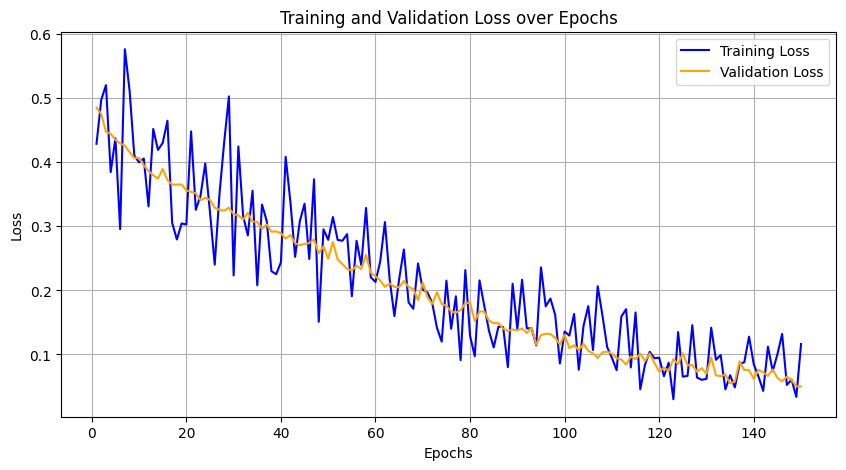

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

Test Accuracy:            0.7848
Weighted Precision:       0.8227
Weighted Recall:          0.7848
Sensitivity:             0.4075
Weighted F1 Score:        0.8012
Specificity:             0.8414
AUC:                     0.7369


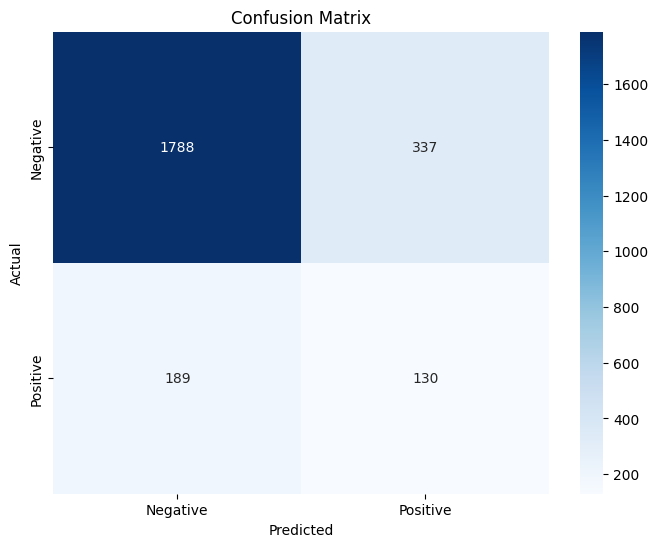

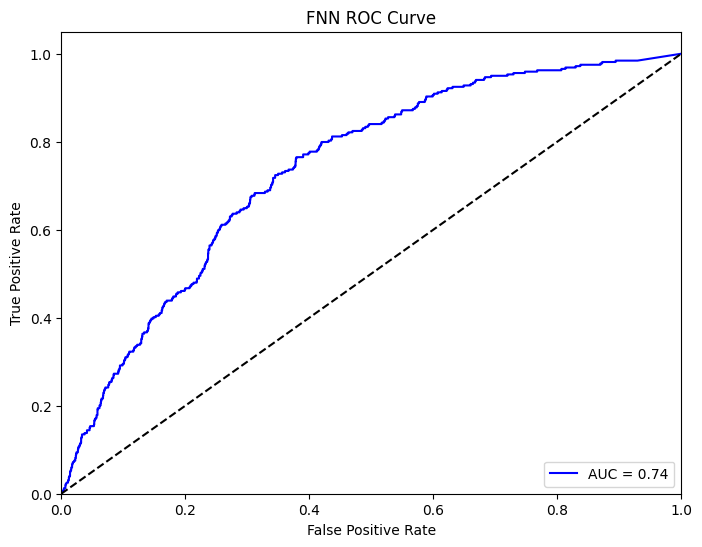

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation on the test set
model.eval()
with torch.no_grad():
    # Concatenate categorical and numerical features for testing
    X_test_combined = torch.cat((X_cat_test, X_num_test), dim=1)
    test_outputs = model(X_test_combined)
    test_predictions = (test_outputs > 0.5).float()  # Convert probabilities to binary predictions

# Convert to NumPy
y_test_np = y_test.numpy()
test_outputs_np = test_outputs.numpy()  # Get the raw output probabilities

# Calculate metrics
accuracy = accuracy_score(y_test_np, test_predictions.numpy())
weighted_precision = precision_score(y_test_np, test_predictions.numpy(), average='weighted')
weighted_recall = recall_score(y_test_np, test_predictions.numpy(), average='weighted')
weighted_f1 = f1_score(y_test_np, test_predictions.numpy(), average='weighted')
conf_matrix = confusion_matrix(y_test_np, test_predictions.numpy())

# Calculate specificity
tn, fp, fn, tp = conf_matrix.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero

# Calculate sensitivity (non-weighted recall)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Avoid division by zero

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_np, test_outputs_np)  # Use raw output probabilities
roc_auc = auc(fpr, tpr)

# Print metrics
print(f"Test Accuracy:            {accuracy:.4f}")
print(f"Weighted Precision:       {weighted_precision:.4f}")
print(f"Weighted Recall:          {weighted_recall:.4f}")
print(f"Sensitivity:             {sensitivity:.4f}")  # Print sensitivity
print(f"Weighted F1 Score:        {weighted_f1:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"AUC:                     {roc_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FNN ROC Curve')
plt.legend(loc='lower right')
# Removed grid lines
plt.show()


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test_np, test_predictions))

              precision    recall  f1-score   support

         0.0       0.90      0.84      0.87      2125
         1.0       0.28      0.41      0.33       319

    accuracy                           0.78      2444
   macro avg       0.59      0.62      0.60      2444
weighted avg       0.82      0.78      0.80      2444



In [19]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

surrogate_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
surrogate_model.fit(X_test, test_predictions)

/Users/tomliu/Library/Python/3.11/lib/python/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=5, random_state=42)

In [22]:
print(len(combined_df))

12216


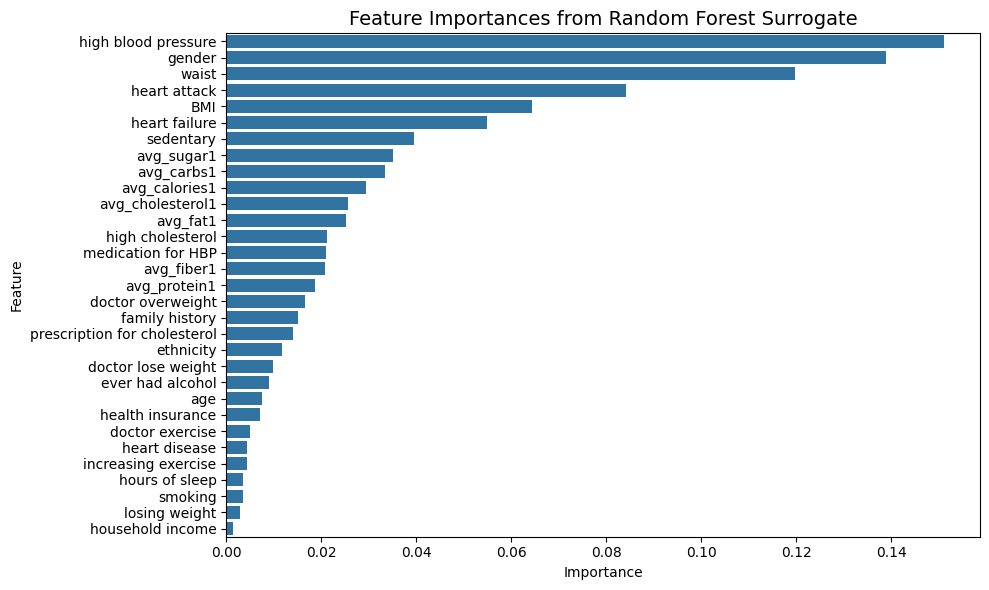

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If X is a NumPy array and you have a DataFrame df with the feature names:
feature_names = combined_df.columns[1:].tolist()

# Get feature importances from the surrogate model
importances = surrogate_model.feature_importances_

# Create a DataFrame to sort and plot
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title("Feature Importances from Random Forest Surrogate", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
